In [1]:
#import required libraries for this session
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Question 1

Read in the csv file and then plot the data. Does the data look stationary?

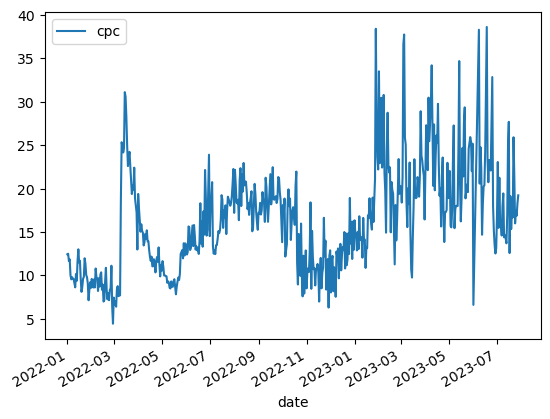

In [2]:
cpc = pd.read_csv('search_cpc.csv', parse_dates=['date'], index_col='date')

fig, ax = plt.subplots()
cpc.plot(ax=ax)
plt.show()

Use the augmented Dicky-Fuller test to check if the data is stationary. If the data isn't stationary, take the first difference and then run the Dicky-Fuller test again. If it still isn't stationary, take a second, third, etc difference. Name your differenced data 'cpc_diff' (You'll need to call on this variable again in a later question). How many differences do we need to take before the data is stationary according to the Dicky-Fuller test?

In [3]:
#check for stationarity

# Import augmented dicky-fuller test function
from statsmodels.tsa.stattools import adfuller

# Run test
result = adfuller(cpc['cpc'])

print(result)

(-2.780654675052007, 0.06109068566585488, 13, 553, {'1%': -3.4422304958001386, '5%': -2.866780664287393, '10%': -2.5695611022893377}, 2930.6091783864813)


In [4]:
#take first difference and check stationarity
cpc_diff = cpc.diff()
cpc_diff = cpc_diff.dropna()

#is the first difference data more stationary?
result_diff = adfuller(cpc_diff['cpc'])
print(result_diff)

(-9.381556106893115, 6.935202955897946e-16, 12, 553, {'1%': -3.4422304958001386, '5%': -2.866780664287393, '10%': -2.5695611022893377}, 2932.5912288999557)


We achieve stationarity after taking the first difference according to the augmented Dicky-Fuller test

# Question 2

In [12]:
ar_coefs = [1, 0.4, -0.1]
ma_coefs = [1, 0.2]

If you were to run this in the arma_generate_sample() function, what would be the order of the data?

ARMA(2,1)

What is the equation for this model?

Yt = -0.4Yt-1 + 0.1Yt-2 + 0.2Et-1 + Et

# Question 3

Fit an AR(2) model to cpc_diff and print the summary of the model fit

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Instantiate the model
model = ARIMA(cpc_diff['cpc'], order=(2,0,0))

# Fit the model
results = model.fit()

# Print summary
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpc   No. Observations:                  566
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1549.497
Date:                Fri, 04 Aug 2023   AIC                           3106.995
Time:                        00:06:35   BIC                           3124.349
Sample:                             0   HQIC                          3113.768
                                - 566                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0112      0.100      0.111      0.911      -0.186       0.208
ar.L1         -0.4229      0.023    -18.778      0.000      -0.467      -0.379
ar.L2         -0.2119      0.033     -6.514      0.0

Using the information in the summary printed, which of the following set of parameters do you think was used to generate the 'cpc' data? Write the parameters out as a list stored as 'ar_coef' for the autoregressive parameters and 'ma_coef' for the moving average parameters

In [ ]:
ar_coef = [1, 0.4, 0.2]
ma_coef = [1]

# Question 4

Instantiate an ARMAX(2,1) model to train on the 'cpc' column of search using the 'impressions' column as an exogenous variable and save the fitted model as a variable called results. What is the coefficient of the exogenous variable?

In [29]:
search = pd.read_csv('search_dataset.csv', parse_dates=['date'], index_col='date')

# Instantiate the ARMAX model
model = ARIMA(search['cpc'], order=(2,0,1), exog=search['impressions'])

# Fit the model
results = model.fit()

# Print model fit summary
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpc   No. Observations:                  567
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -1529.801
Date:                Fri, 04 Aug 2023   AIC                           3071.601
Time:                        01:08:32   BIC                           3097.644
Sample:                             0   HQIC                          3081.765
                                - 567                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.2721      2.023      8.045      0.000      12.308      20.236
impressions -7.622e-05      0.000     -0.308      0.758      -0.001       0.000
ar.L1           1.0870      0.080     13.525    

Coefficient of exogeneous variable is -.00007622

# Question 5

Generate an out of sample prediction for 30 days into the future, extract the mean of your predictions and print the mean predictions 

In [28]:
#run this first
model = ARIMA(cpc['cpc'], order=(2,1,0))
results = model.fit()

#write rest of your answer here
future_forecast = results.get_forecast(steps=30)
mean_forecast = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()
lower_limits = confidence_intervals.loc[:,'lower cpc']
upper_limits = confidence_intervals.loc[:,'upper cpc']
print(mean_forecast)

567    18.532150
568    18.632327
569    18.735716
570    18.670767
571    18.676326
572    18.687738
573    18.681734
574    18.681855
575    18.683076
576    18.682534
577    18.682504
578    18.682631
579    18.682584
580    18.682577
581    18.682590
582    18.682586
583    18.682585
584    18.682586
585    18.682586
586    18.682586
587    18.682586
588    18.682586
589    18.682586
590    18.682586
591    18.682586
592    18.682586
593    18.682586
594    18.682586
595    18.682586
596    18.682586
Name: predicted_mean, dtype: float64


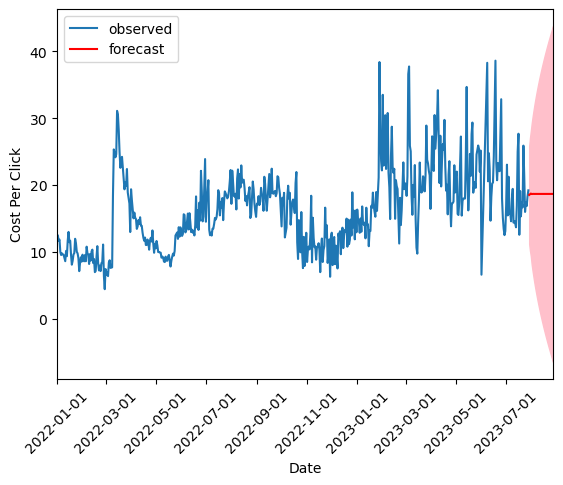

In [26]:
#BONUS
import matplotlib.dates as mdates

forecast_dates = pd.date_range(start=cpc.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
forecast_series = pd.Series(mean_forecast.values, index=forecast_dates)

plt.figure()

plt.plot(cpc.index, cpc, label='observed')
plt.plot(forecast_series.index, forecast_series, color='r', label='forecast')

#shade area between confidence limits
plt.fill_between(forecast_series.index, lower_limits, upper_limits, color='pink')

#set labels, legends and show plot
plt.xlabel('Date')
plt.ylabel('Cost Per Click')
plt.legend()

start_date = pd.to_datetime(cpc.index[0])
end_date = pd.to_datetime(forecast_series.index[-1])
plt.xlim(start_date, end_date)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.show()